# 02 - Pré-processamento e modelagem

## Objetivo

Partindo dos dados limpos do notebook 01, este notebook:

1. divide os dados em **treino, validação e teste**;
2. monta o **pipeline de pré-processamento**;
3. testa se **reduzir medidas** ajuda;
4. **ajusta os hiperparâmetros** de 4 modelos candidatos;
5. escolhe o **limiar de decisão** de cada um;
6. compara os candidatos na **validação** e escolhe o modelo final;
7. salva o modelo final em `models/modelo_final.joblib` para o notebook 03.

> **Regra de ouro:** o conjunto de **teste não é usado aqui**. Ele fica guardado para medir o modelo escolhido **uma única vez** no notebook 03. Se o usássemos para escolher, o resultado do teste ficaria otimista demais.



## Guia rápido das métricas

Em todas as métricas, a classe "positiva" é o **maligno (M)**.

| Termo | O que é | Neste problema |
|---|---|---|
| **Falso negativo (FN)** | maligno classificado como benigno | **o erro mais grave**: um câncer que passa despercebido |
| **Falso positivo (FP)** | benigno classificado como maligno | erro menos grave: gera um exame ou uma revisão a mais |
| **Recall (sensibilidade)** | dos malignos reais, quantos o modelo encontrou | **métrica principal**. Recall 0,97 = encontrou 97 de cada 100 malignos |
| **Precisão** | dos casos que o modelo chamou de maligno, quantos eram mesmo | mede o "alarme falso". Precisão 0,94 = 6 de cada 100 alertas eram benignos |
| **F1** | média (harmônica) entre recall e precisão, com pesos iguais | equilíbrio entre os dois erros |
| **F2** | como o F1, mas o **recall pesa o dobro** | **critério usado para ajustar e escolher**, porque o FN é pior que o FP |
| **Accuracy** | acertos / total | fácil de entender, mas esconde os FN quando as classes são desbalanceadas |
| **Limiar** | probabilidade a partir da qual o caso é chamado de maligno | o padrão é 0,50; baixar o limiar encontra mais malignos (↑ recall) ao custo de mais alarmes falsos (↓ precisão) |


In [1]:
from functools import partial

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import GridSearchCV, TunedThresholdClassifierCV, cross_val_predict, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from triagem_mama.config import (CAMINHO_MODELO_FINAL, CLASSE_POSITIVA, CLASSES, NOMES_CLASSES,
                                PASTA_FIGURAS, PASTA_MODELOS, SEED)
from triagem_mama.dados import carregar_dados, dividir_dados, separar_X_y
from triagem_mama.modelagem import (calcular_metricas, colunas_sem_redundancia, criar_candidatos,
                                    criar_cv, criar_pipeline, scorer_f2, scorer_recall)

PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)


def decimal(valor, casas=2):
    # Formata número com vírgula decimal, para os rótulos dos gráficos.
    return f"{valor:.{casas}f}".replace(".", ",")


## 1. Divisão em treino, validação e teste

| Conjunto | Tamanho | Para que serve |
|---|---|---|
| **Treino** | 70% | o modelo **aprende** aqui. Também é onde ajustamos hiperparâmetros e limiar, com validação cruzada |
| **Validação** | 15% | **compara** os candidatos já ajustados e escolhe o vencedor |
| **Teste** | 15% | **nota final** do vencedor, usada uma única vez (notebook 03) |

- A divisão é **estratificada**: cada parte mantém a proporção de ~37% malignos.
- A seed é fixa (`random_state=42`), então o resultado é reprodutível.
- A função `dividir_dados()` em `src/triagem_mama/dados.py` garante que o notebook 03 use **exatamente o mesmo** teste.

In [2]:
X, y = separar_X_y(carregar_dados())
divisao = dividir_dados(X, y)

X_treino, y_treino = divisao.X_treino, divisao.y_treino
X_val, y_val = divisao.X_val, divisao.y_val
# divisao.X_teste fica fora deste notebook. Abaixo contamos só quantos exames ele tem.

conjuntos = {"Treino": y_treino, "Validação": y_val, "Teste": divisao.y_teste}
pd.DataFrame({
    "Exames": {nome: len(s) for nome, s in conjuntos.items()},
    "% do total": {nome: round(100 * len(s) / len(y), 1) for nome, s in conjuntos.items()},
    "Malignos": {nome: int((s == CLASSE_POSITIVA).sum()) for nome, s in conjuntos.items()},
    "% malignos": {nome: round(100 * (s == CLASSE_POSITIVA).mean(), 1) for nome, s in conjuntos.items()},
})


,Exames,% do total,Malignos,% malignos
Treino,397,69.8,148,37.3
Validação,86,15.1,32,37.2
Teste,86,15.1,32,37.2


**Conclusão:** treino com 397 exames, validação com 86 e teste com 86. Os três têm 37,2–37,3% de malignos, igual à base completa, e a estratificação funcionou. Validação e teste têm 32 malignos cada: cada maligno perdido derruba o recall em cerca de 3 pontos (1/32 ≈ 0,031). Diferenças de um ou dois casos entre modelos devem ser lidas com cautela.

## 2. Pipeline de pré-processamento

O pipeline (função `criar_pipeline()` em `src/triagem_mama/modelagem.py`) junta, num único objeto:

1. **`ColumnTransformer`**: escolhe as colunas usadas pelo modelo e aplica o **`StandardScaler`** em cada uma (média 0 e desvio 1, como visto no notebook 01).
2. **O classificador.**

**Por que montar tudo junto?** Quando chamamos `pipeline.fit(X_treino, y_treino)`, o scaler calcula médias e desvios **só com o treino**. Validação e teste são transformados com esses mesmos números. Se padronizássemos a base inteira antes de dividir, o modelo "veria" informação do teste: isso é **vazamento de dados (leakage)**, e o resultado ficaria otimista demais.

**E as variáveis categóricas?** Todas as 30 medidas são numéricas. A única coluna categórica é o próprio alvo (B/M), que o scikit-learn trata diretamente como rótulo. Por isso não precisamos de OneHotEncoder.

In [3]:
pipeline_exemplo = criar_pipeline(LogisticRegression(max_iter=5000, random_state=SEED), X.columns)
pipeline_exemplo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessador', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{

In [4]:
# Demonstração: o scaler aprende com o treino e só APLICA o que aprendeu na validação.
preprocessador = pipeline_exemplo.named_steps["preprocessador"].fit(X_treino)
treino_padronizado = pd.DataFrame(preprocessador.transform(X_treino), columns=X.columns)
val_padronizado = pd.DataFrame(preprocessador.transform(X_val), columns=X.columns)

exemplos = ["radius_mean", "area_worst", "smoothness_mean"]
pd.DataFrame({
    "Valor original (média no treino)": X_treino[exemplos].mean(),
    "Média padronizada (treino)": treino_padronizado[exemplos].mean(),
    "Desvio padronizado (treino)": treino_padronizado[exemplos].std(ddof=0),
    "Média padronizada (validação)": val_padronizado[exemplos].mean(),
}).round(3)


,Valor original (média no treino),Média padronizada (treino),Desvio padronizado (treino),Média padronizada (validação)
radius_mean,14.161,-0.0,1.0,-0.002
area_worst,884.968,0.0,1.0,0.024
smoothness_mean,0.096,-0.0,1.0,0.079


**Leitura:** no treino, média 0 e desvio 1 exatos, porque foi com esses dados que o scaler aprendeu. Na validação, as médias ficam **perto de zero, mas não exatamente zero**. É o comportamento correto: a validação foi transformada com a régua do treino, como acontecerá com um exame novo no futuro.

## 3. Experimento: vale a pena reduzir as medidas?

O notebook 01 mostrou muita redundância. Testamos 4 conjuntos de medidas nos 3 algoritmos, com hiperparâmetros padrão:

- **Todas (30)**;
- **Sem redundância (24)**: remove `perimeter_*` e `area_*` e mantém `radius_*`;
- **Top 15 / Top 10**: seleção automática pelas medidas de maior **informação mútua** com o alvo (`SelectKBest`).

**Como medimos:** validação cruzada estratificada com **5 partes (folds), só no treino**. O treino é dividido em 5 partes; o modelo treina com 4 e é avaliado na quinta, 5 vezes. A seleção automática também é refeita dentro de cada fold, para não vazar informação. Mostramos a média ± o desvio entre os folds.


In [5]:
info_mutua = partial(mutual_info_classif, random_state=SEED)
algoritmos = {
    "Regressão Logística": lambda: LogisticRegression(max_iter=5000, random_state=SEED),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "KNN": lambda: KNeighborsClassifier(),
}


def pipeline_com_selecao(classificador, k):
    base = criar_pipeline(classificador, X.columns)
    return Pipeline([base.steps[0], ("selecao", SelectKBest(info_mutua, k=k)), base.steps[1]])


variantes = {
    "Todas (30)": lambda c: criar_pipeline(c, X.columns),
    "Sem redundância (24)": lambda c: criar_pipeline(c, colunas_sem_redundancia(X.columns)),
    "Top 15 (info. mútua)": lambda c: pipeline_com_selecao(c, 15),
    "Top 10 (info. mútua)": lambda c: pipeline_com_selecao(c, 10),
}

linhas = []
for nome_algoritmo, criar_classificador in algoritmos.items():
    for nome_variante, montar in variantes.items():
        r = cross_validate(montar(criar_classificador()), X_treino, y_treino, cv=criar_cv(),
                           scoring={"F2": scorer_f2, "Recall": scorer_recall}, n_jobs=-1)
        linhas.append({
            "Modelo": nome_algoritmo,
            "Medidas": nome_variante,
            "F2 (M)": f"{r['test_F2'].mean():.3f} ± {r['test_F2'].std():.3f}",
            "Recall (M)": f"{r['test_Recall'].mean():.3f} ± {r['test_Recall'].std():.3f}",
        })
pd.DataFrame(linhas).set_index(["Modelo", "Medidas"])


F2 (M)     Recall (M)
Modelo              Medidas                                           
Regressão Logística Todas (30)            0.951 ± 0.033  0.946 ± 0.040
                    Sem redundância (24)  0.948 ± 0.031  0.940 ± 0.039
                    Top 15 (info. mútua)  0.914 ± 0.063  0.906 ± 0.072
                    Top 10 (info. mútua)  0.919 ± 0.073  0.913 ± 0.086
Random Forest       Todas (30)            0.920 ± 0.063  0.912 ± 0.072
                    Sem redundância (24)  0.923 ± 0.063  0.913 ± 0.078
                    Top 15 (info. mútua)  0.900 ± 0.078  0.892 ± 0.093
                    Top 10 (info. mútua)  0.891 ± 0.082  0.886 ± 0.103
KNN                 Todas (30)            0.909 ± 0.065  0.892 ± 0.078
                    Sem redundância (24)  0.890 ± 0.067  0.872 ± 0.080
                    Top 15 (info. mútua)  0.897 ± 0.072  0.892 ± 0.086
                    Top 10 (info. mútua)  0.874 ± 0.076  0.866 ± 0.099

**Conclusão do experimento:**

- **A seleção automática (Top 15 / Top 10) piorou todos os modelos**, tanto no F2 quanto no recall. Descartar medidas "fracas" sozinhas tira informação que só aparece na combinação com outras.
- **Remover perímetro e área quase não muda o desempenho** da Regressão Logística (F2 0,948 × 0,951) e do Random Forest (0,923 × 0,920). A diferença é muito menor que o desvio entre folds (~0,03 a 0,06). No KNN, piorou (0,890 × 0,909).
- **Decisão:** mantemos as 30 medidas nos três algoritmos e adicionamos um **4º candidato: Regressão Logística sem redundância**. Ela prevê tão bem quanto a completa e tem uma vantagem: sem medidas quase idênticas, os pesos ficam mais fáceis de interpretar. Os ajustes a seguir dizem se ela se sustenta.


## 4. Ajuste de hiperparâmetros

**Hiperparâmetros** como as "configurações" de um modelo que não são aprendidas dos dados e precisamos escolher. Antes, os modelos usavam os valores padrão. Agora testamos combinações com **`GridSearchCV`**: cada combinação é avaliada pela mesma validação cruzada de 5 folds **no treino**, e fica a de **maior F2**.

| Modelo | O que é | Hiperparâmetros testados |
|---|---|---|
| **Regressão Logística** (2 versões) | soma ponderada das medidas transformada em probabilidade (curva sigmoide). Simples e interpretável | `C` (força da regularização: menor = pesos mais contidos, menos risco de decorar o treino); `class_weight` (None ou `balanced`) |
| **Random Forest** | comitê de 300 árvores de decisão, cada uma treinada com uma amostra diferente dos dados; a decisão é o voto da maioria. Capta relações não lineares | `max_depth` (profundidade máxima das árvores); `min_samples_leaf` (mínimo de exames por folha: maior = árvores mais "generalistas"); `class_weight` |
| **KNN** | classifica um exame pelos `k` exames mais parecidos do treino | `n_neighbors` (k); `weights` (vizinhos com o mesmo peso ou com peso maior para os mais próximos) |

`class_weight="balanced"` faz o modelo dar **mais peso aos malignos** no treino, para compensar que eles são minoria.


In [6]:
candidatos = criar_candidatos(X.columns)
buscas = {}
linhas = []
for nome, (pipeline, grade) in candidatos.items():
    busca = GridSearchCV(pipeline, grade, scoring={"F2": scorer_f2, "Recall": scorer_recall},
                         refit="F2", cv=criar_cv(), n_jobs=-1)
    busca.fit(X_treino, y_treino)
    buscas[nome] = busca
    i, r = busca.best_index_, busca.cv_results_
    linhas.append({
        "Modelo": nome,
        "Combinações testadas": len(r["params"]),
        "Melhores hiperparâmetros": ", ".join(
            f"{k.removeprefix('classificador__')}={v}" for k, v in busca.best_params_.items()
        ),
        "F2 (CV no treino)": f"{r['mean_test_F2'][i]:.3f} ± {r['std_test_F2'][i]:.3f}",
        "Recall (CV no treino)": f"{r['mean_test_Recall'][i]:.3f} ± {r['std_test_Recall'][i]:.3f}",
    })
pd.DataFrame(linhas).set_index("Modelo")

,Combinações testadas,Melhores hiperparâmetros,F2 (CV no treino),Recall (CV no treino)
Modelo,,,,
Regressão Logística,10,"C=0.1, class_weight=balanced",0.965 ± 0.029,0.960 ± 0.039
Regressão Logística (sem redundância),10,"C=1, class_weight=balanced",0.957 ± 0.031,0.953 ± 0.034
Random Forest,18,"class_weight=balanced, max_depth=None, min_sam...",0.944 ± 0.036,0.946 ± 0.046
KNN,12,"n_neighbors=5, weights=uniform",0.909 ± 0.065,0.892 ± 0.078


**Conclusão do ajuste:**

- **As duas Regressões Logísticas lideram:** F2 de 0,965 (completa) e 0,957 (sem redundância), com recall perto de 0,96. Ambas escolheram `class_weight="balanced"`, o que confirma que dar mais peso aos malignos ajuda a encontrá-los.
- **Random Forest** fica um pouco atrás (F2 0,944) e também preferiu `balanced`.
- **KNN** ficou com os valores padrão (k=5) e é o mais fraco e instável: F2 0,909 com o maior desvio (± 0,065).
- O ajuste melhorou a Regressão Logística em relação aos valores padrão do experimento anterior (F2 0,951 → 0,965).
- **Todas as diferenças são pequenas** perto do desvio entre folds. Por isso a escolha final não depende só deste número.

## 5. Limiar de decisão

O modelo não responde "benigno" ou "maligno" diretamente: ele calcula uma **probabilidade de maligno**, e o **limiar** decide a partir de qual valor o caso é sinalizado. O padrão é 0,50, mas nada obriga a usá-lo. Numa **triagem**, faz sentido sinalizar mais cedo, aceitando alguns alarmes falsos a mais para perder menos malignos.

Usamos o **`TunedThresholdClassifierCV`** do scikit-learn. Para cada candidato (já com os melhores hiperparâmetros), ele:

1. faz validação cruzada de 5 folds **no treino**;
2. testa vários limiares e fica com o de **maior F2**;
3. treina o modelo de novo com **todo o treino**, guardando o limiar escolhido.

Validação e teste continuam de fora.

In [7]:
modelos_finais = {}
for nome, busca in buscas.items():
    ajuste = TunedThresholdClassifierCV(busca.best_estimator_, scoring=scorer_f2, cv=criar_cv())
    modelos_finais[nome] = ajuste.fit(X_treino, y_treino)

pd.DataFrame({
    "Limiar escolhido": {nome: m.best_threshold_ for nome, m in modelos_finais.items()},
    "F2 (CV no treino) com esse limiar": {nome: m.best_score_ for nome, m in modelos_finais.items()},
}).round(3)

,Limiar escolhido,F2 (CV no treino) com esse limiar
Regressão Logística,0.344,0.963
Regressão Logística (sem redundância),0.333,0.961
Random Forest,0.485,0.949
KNN,0.202,0.939


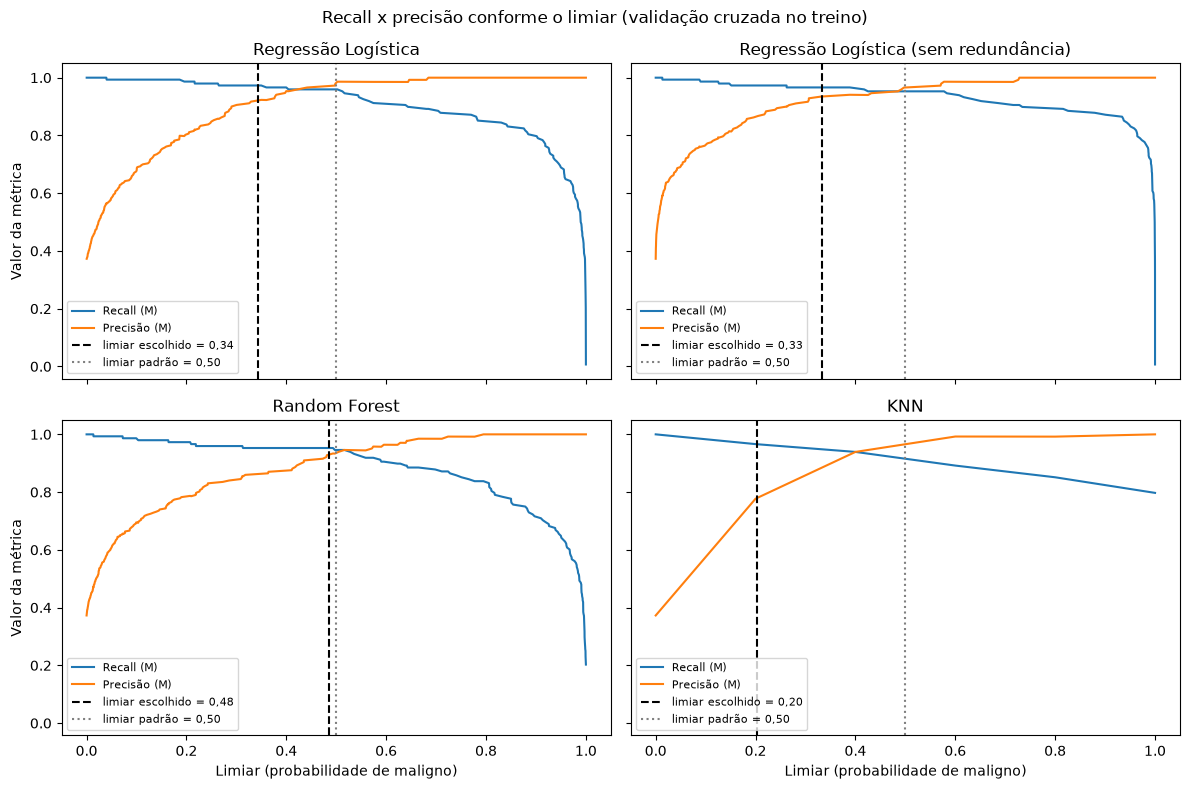

In [8]:
# Visualização do "cabo de guerra" entre recall e precisão conforme o limiar muda.
# As probabilidades vêm de validação cruzada no treino: cada exame é previsto por um
# modelo que NÃO o viu no treino (previsões "fora do fold").
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, (nome, busca) in zip(axes.flat, buscas.items()):
    prob = cross_val_predict(busca.best_estimator_, X_treino, y_treino, cv=criar_cv(),
                             method="predict_proba")[:, CLASSES.index(CLASSE_POSITIVA)]
    precisao, recall, limiares = precision_recall_curve(y_treino == CLASSE_POSITIVA, prob)
    ax.plot(limiares, recall[:-1], label="Recall (M)")
    ax.plot(limiares, precisao[:-1], label="Precisão (M)")
    ax.axvline(modelos_finais[nome].best_threshold_, color="black", linestyle="--",
               label=f"limiar escolhido = {decimal(modelos_finais[nome].best_threshold_)}")
    ax.axvline(0.5, color="gray", linestyle=":", label="limiar padrão = 0,50")
    ax.set_title(nome)
    ax.legend(loc="lower left", fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Limiar (probabilidade de maligno)")
for ax in axes[:, 0]:
    ax.set_ylabel("Valor da métrica")
fig.suptitle("Recall x precisão conforme o limiar (validação cruzada no treino)")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "limiar_recall_precisao.png", dpi=150)
plt.show()

**Conclusão:**

- Nas **Regressões Logísticas**, o limiar ideal ficou em **~0,33–0,34**: basta 1/3 de probabilidade para o caso ser sinalizado. Nos gráficos, abaixo de ~0,3 a precisão cai mais rápido do que o recall sobe.
- No **Random Forest**, o limiar quase não mudou (0,48): o `class_weight="balanced"` já deslocou as probabilidades.
- No **KNN**, o limiar foi para 0,20. Com k=5, a probabilidade só assume os valores 0, 0,2, 0,4... Isso quer dizer "sinalize se **pelo menos 1** dos 5 vizinhos for maligno".
- Este é um **ajuste técnico** feito com F2. Num uso real, o ponto de corte deve ser **definido junto com a equipe clínica**, conforme quantos alarmes falsos ela aceita revisar.


## 6. Comparação na validação e escolha do modelo

Agora usamos a **validação**, que nenhum modelo viu até aqui. A **regra de escolha foi definida antes** de olhar os resultados:

1. maior **recall (M)** na validação, porque perder malignos é o pior erro;
2. em caso de empate, maior **F2** na validação, que inclui a precisão;
3. se ainda empatar, maior **F2 na validação cruzada do treino**, uma estimativa feita com mais dados (397 × 86 exames) e, por isso, mais estável.

In [14]:
f2_cv_treino = {nome: b.cv_results_["mean_test_F2"][b.best_index_] for nome, b in buscas.items()}

linhas = []
for nome, modelo in modelos_finais.items():
    linhas.append({
        "Modelo": nome,
        "Limiar": modelo.best_threshold_,
        **calcular_metricas(y_val, modelo.predict(X_val)),
        "F2 (CV no treino)": f2_cv_treino[nome],
    })
comparacao_val = (pd.DataFrame(linhas).set_index("Modelo")
                  .sort_values(["Recall (M)", "F2 (M)", "F2 (CV no treino)"], ascending=False))
vencedor = comparacao_val.index[0]

display(comparacao_val.round(3))
print(f"Modelo escolhido: {vencedor}")

,Limiar,Recall (M),Precisão (M),F1 (M),F2 (M),Accuracy,Falso negativos,Falso positivos,F2 (CV no treino)
Modelo,,,,,,,,,
Regressão Logística (sem redundância),0.333,1.000,0.941,0.970,0.988,0.977,0,2,0.957
KNN,0.202,1.000,0.941,0.970,0.988,0.977,0,2,0.909
Regressão Logística,0.344,1.000,0.865,0.928,0.970,0.942,0,5,0.965
Random Forest,0.485,0.938,0.968,0.952,0.943,0.965,2,1,0.944


Modelo escolhido: Regressão Logística (sem redundância)


In [15]:
# Para referência: as mesmas métricas na validação com o limiar padrão (0,50).
pd.DataFrame.from_dict({nome: calcular_metricas(y_val, b.best_estimator_.predict(X_val))
                        for nome, b in buscas.items()}, orient="index").round(3)

,Recall (M),Precisão (M),F1 (M),F2 (M),Accuracy,Falso negativos,Falso positivos
Regressão Logística,0.969,0.969,0.969,0.969,0.977,1,1
Regressão Logística (sem redundância),0.969,0.939,0.954,0.963,0.965,1,2
Random Forest,0.938,0.968,0.952,0.943,0.965,2,1
KNN,0.969,0.969,0.969,0.969,0.977,1,1


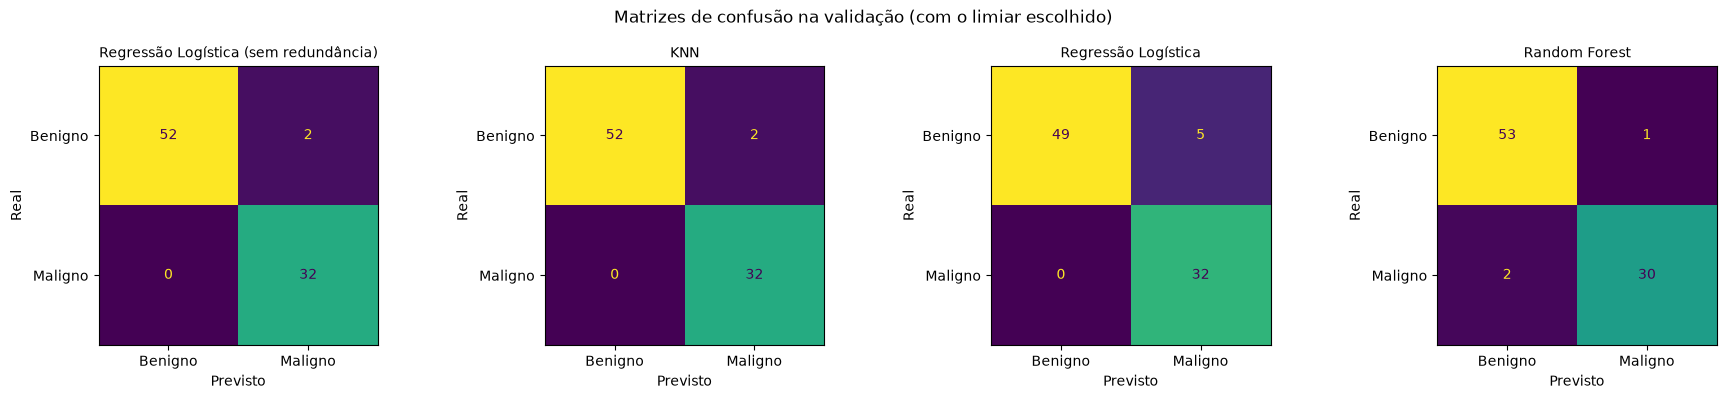

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, nome in zip(axes, comparacao_val.index):
    ConfusionMatrixDisplay.from_predictions(
        y_val, modelos_finais[nome].predict(X_val), labels=CLASSES,
        display_labels=[NOMES_CLASSES[c] for c in CLASSES], colorbar=False, ax=ax)
    ax.set_title(nome, fontsize=10)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
fig.suptitle("Matrizes de confusão na validação (com o limiar escolhido)")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "matrizes_confusao_validacao.png", dpi=150)
plt.show()


**Conclusão: a Regressão Logística sem redundância é o modelo escolhido.**

- **Critério 1 (recall):** três modelos encontraram **todos os 32 malignos** da validação (recall 1,000): as duas Regressões Logísticas e o KNN. O Random Forest perdeu 2 (recall 0,938) e saiu da disputa.
- **Critério 2 (F2):** a LR sem redundância e o KNN empataram (F2 0,988, com 2 falsos positivos cada). A LR completa gerou 5 falsos positivos (F2 0,970).
- **Critério 3 (desempate):** no F2 da validação cruzada do treino, a LR sem redundância (0,957) supera com folga o KNN (0,909), que também foi o modelo mais instável entre folds.
- **O limiar fez diferença:** com o limiar padrão de 0,50, os três primeiros colocados perderiam 1 maligno cada na validação. Com o limiar ajustado, não perderam nenhum.

**Cautelas:**

- As diferenças entre os três primeiros são de **2 a 3 exames** em 86. A escolha é razoável, não definitiva.
- A LR sem redundância tem um bônus que não aparece nas métricas: com menos medidas quase idênticas, os pesos são mais fáceis de explicar a um médico (notebook 03).

## 7. Salvando o modelo final

O arquivo salvo contém o **pipeline treinado** (pré-processamento + Regressão Logística) **e o limiar escolhido**. O notebook 03 só carrega esse arquivo: não treina nada de novo.

> `joblib` usa o formato **pickle** do Python. Carregue apenas arquivos gerados por você ou por fonte confiável, nunca um `.joblib` de origem desconhecida.

In [17]:
modelo_final = modelos_finais[vencedor]
artefato = {
    "nome": vencedor,
    "modelo": modelo_final,  # TunedThresholdClassifierCV: pipeline treinado + limiar
    "limiar": float(modelo_final.best_threshold_),
    "hiperparametros": {k.removeprefix("classificador__"): v for k, v in buscas[vencedor].best_params_.items()},
    "colunas_usadas": list(modelo_final.estimator_.named_steps["preprocessador"].get_feature_names_out()),
    "metricas_validacao": comparacao_val.loc[vencedor].to_dict(),
}
PASTA_MODELOS.mkdir(parents=True, exist_ok=True)
joblib.dump(artefato, CAMINHO_MODELO_FINAL)

print(f"Salvo em: {CAMINHO_MODELO_FINAL.relative_to(CAMINHO_MODELO_FINAL.parents[1]).as_posix()}")
print(f"Modelo: {artefato['nome']} | limiar: {artefato['limiar']:.3f} | hiperparâmetros: {artefato['hiperparametros']}")
print(f"Medidas usadas ({len(artefato['colunas_usadas'])}): {', '.join(artefato['colunas_usadas'])}")

Salvo em: models/modelo_final.joblib
Modelo: Regressão Logística (sem redundância) | limiar: 0.333 | hiperparâmetros: {'C': 1, 'class_weight': 'balanced'}
Medidas usadas (24): radius_mean, texture_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst


## Resumo do notebook 02

| Etapa | Resultado |
|---|---|
| Split | 397 treino / 86 validação / 86 teste, estratificado (37% malignos em cada) |
| Pipeline | `ColumnTransformer` + `StandardScaler` + classificador, ajustado só no treino |
| Redução de medidas | Seleção automática piorou; remover perímetro e área manteve o desempenho da LR |
| Ajuste | `GridSearchCV` (5 folds no treino, critério F2). As LRs lideraram, com `class_weight="balanced"` |
| Limiar | Escolhido por F2 na CV do treino: ~0,33 nas LRs, em vez de 0,50 |
| Escolha (validação) | **Regressão Logística sem redundância**: recall 1,000, precisão 0,941, F2 0,988, 2 falsos positivos |
| Saída | `models/modelo_final.joblib` |

Próximo passo: o **notebook 03** mede esse modelo no teste (uma única vez), explica suas decisões (importância e SHAP) e discute o uso prático.